# VNI Data Cleaning and Forecasting

This notebook is a VNI-focused version of `clean_data.ipynb`. It loads `VNI.csv`, cleans numeric columns, and builds ARIMA/Prophet forecasts on the Close series.

In [1]:
# Install only if needed in your current kernel
# %pip install pandas numpy matplotlib statsmodels scikit-learn prophet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [2]:
def parse_number(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().replace(',', '')
    if s == '':
        return np.nan
    return float(s)

def parse_volume(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().upper().replace(',', '')
    if s == '':
        return np.nan

    mult = 1.0
    if s.endswith('K'):
        mult = 1_000.0
        s = s[:-1]
    elif s.endswith('M'):
        mult = 1_000_000.0
        s = s[:-1]

    return float(s) * mult

In [8]:
df = pd.read_csv(
r"C:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\VNI.csv",
sep=";",
thousands=","
)

# Drop trailing empty column if present from CSV export
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


df = df.sort_values('Date').dropna(subset=['Close']).reset_index(drop=True)
def parse_volume(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)

    text = str(value).strip().replace(',', '')
    multipliers = {'K': 1_000, 'M': 1_000_000, 'B': 1_000_000_000}

    suffix = text[-1].upper() if text else ''
    if suffix in multipliers:
        number_part = pd.to_numeric(text[:-1], errors='coerce')
        return number_part * multipliers[suffix] if not pd.isna(number_part) else np.nan

    return pd.to_numeric(text, errors='coerce')
df['Date'] = pd.to_datetime(df['Date'])
df['Volume'] = df['Volume'].apply(parse_volume)
print('Shape:', df.shape)
display(df.head())
display(df.tail())

Shape: (4808, 6)


,Date,Open,High,Low,Close,Volume
0,2007-01-02,751.04,751.04,741.27,741.27,6350.0
1,2007-01-03,745.13,757.71,745.13,757.71,5930.0
2,2007-01-04,784.45,788.82,784.45,788.82,10800.0
3,2007-01-05,818.04,818.04,816.51,816.51,11080.0
4,2007-01-08,840.22,840.22,825.11,825.11,11610.0


,Date,Open,High,Low,Close,Volume
4803,2026-04-15,1775.65,1801.89,1775.39,1800.65,805510000.0
4804,2026-04-16,1800.65,1824.03,1795.42,1819.83,819390000.0
4805,2026-04-17,1819.83,1846.19,1812.24,1817.17,632350000.0
4806,2026-04-20,1813.42,1838.74,1802.42,1832.81,690090000.0
4807,2026-04-21,1823.24,1866.10,1823.24,1847.05,608830000.0


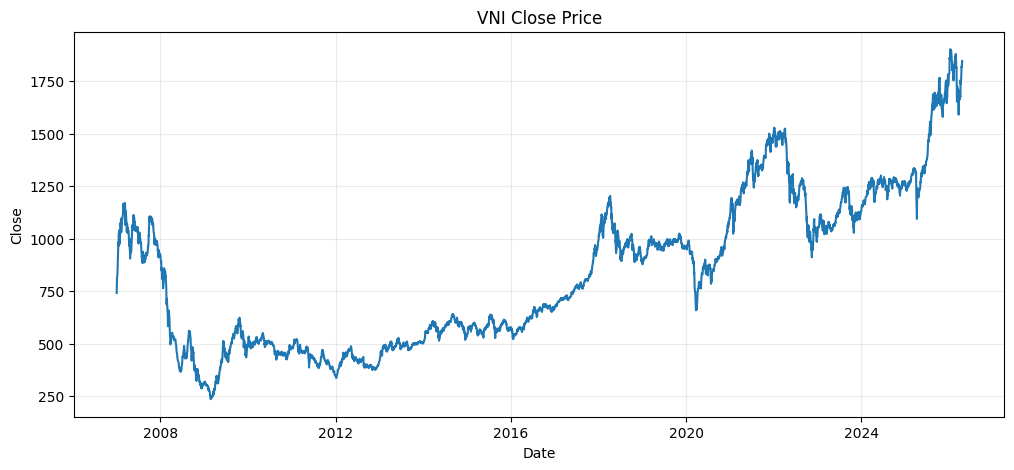

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='tab:blue', linewidth=1.5)
plt.title('VNI Close Price')
plt.xlabel('Date')
plt.ylabel('Close')
plt.grid(True, alpha=0.25)
plt.show()

In [10]:
series = df.set_index('Date')['Close']

split_idx = int(len(series) * 0.8)
train = series.iloc[:split_idx]
test = series.iloc[split_idx:]

print(f'Train size: {len(train)} | Test size: {len(test)}')

# Baseline ARIMA order, easy to tune later
order = (5, 1, 0)
model = ARIMA(train, order=order)
model_fit = model.fit()

pred = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test, pred))
mae = mean_absolute_error(test, pred)
mape = mean_absolute_percentage_error(test, pred) * 100

print('ARIMA order:', order)
print(f'RMSE: {rmse:.3f}')
print(f'MAE : {mae:.3f}')
print(f'MAPE: {mape:.3f}%')

Train size: 3846 | Test size: 962


c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA order: (5, 1, 0)
RMSE: 241.792
MAE : 165.434
MAPE: 11.635%


c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


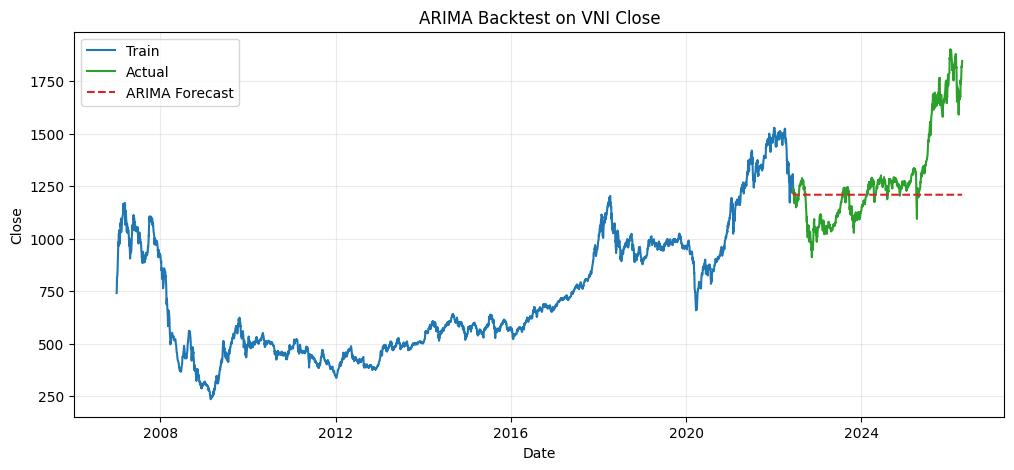

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train', color='tab:blue')
plt.plot(test.index, test, label='Actual', color='tab:green')
plt.plot(test.index, pred, label='ARIMA Forecast', color='tab:red', linestyle='--')
plt.title('ARIMA Backtest on VNI Close')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Seri

,Date,ARIMA_Forecast
0,2026-04-22,1850.247465
1,2026-04-23,1851.340676
2,2026-04-24,1851.747270
3,2026-04-27,1853.018316
4,2026-04-28,1854.038418


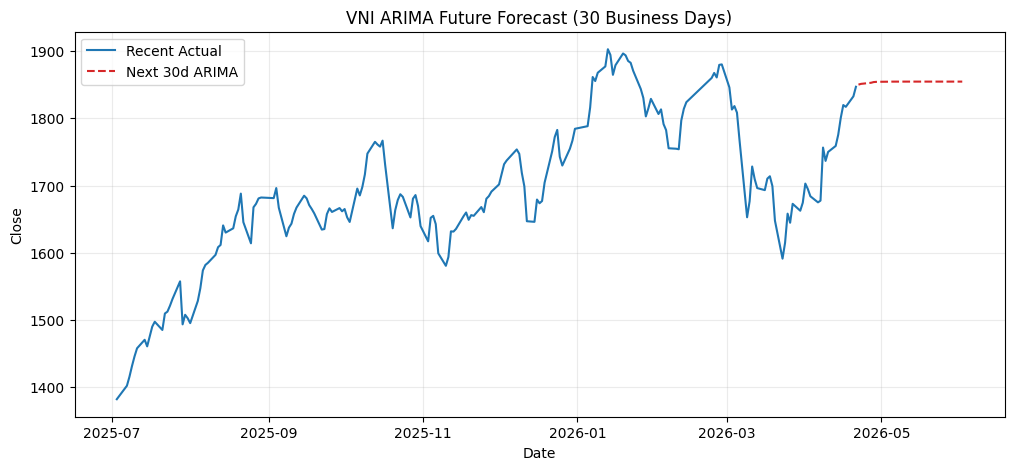

In [12]:
# Fit on full history and forecast next 30 business days
future_steps = 30
final_model = ARIMA(series, order=(5, 1, 0)).fit()
future_arima = final_model.forecast(steps=future_steps)
future_dates = pd.bdate_range(series.index[-1] + pd.offsets.BDay(1), periods=future_steps)

arima_fc_df = pd.DataFrame({'Date': future_dates, 'ARIMA_Forecast': future_arima.values})
display(arima_fc_df.head())

plt.figure(figsize=(12, 5))
plt.plot(series.index[-200:], series.values[-200:], label='Recent Actual', color='tab:blue')
plt.plot(arima_fc_df['Date'], arima_fc_df['ARIMA_Forecast'], label='Next 30d ARIMA', color='tab:red', linestyle='--')
plt.title('VNI ARIMA Future Forecast (30 Business Days)')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

=== GIAI DOAN 1: CHUAN BI DU LIEU ===
So dong Train: 3846 | So dong Test: 962

=== GIAI DOAN 2: ARIMA WALK-FORWARD (NO FUTURE LEAK) ===


c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Seri


=== GIAI DOAN 3: LSTM HOC PHAN DU ===
Dang huan luyen LSTM tren phan du...
Epoch da dung: 30
Residual weight (calibrated): 0.200

=== GIAI DOAN 4: HYBRID WALK-FORWARD TEST ===

=== KET QUA TEST CUA HYBRID WALK-FORWARD (ARIMA + LSTM) ===
ARIMA order: (5, 1, 0)
RMSE : 17.970
MAE  : 12.675
MAPE : 0.963%


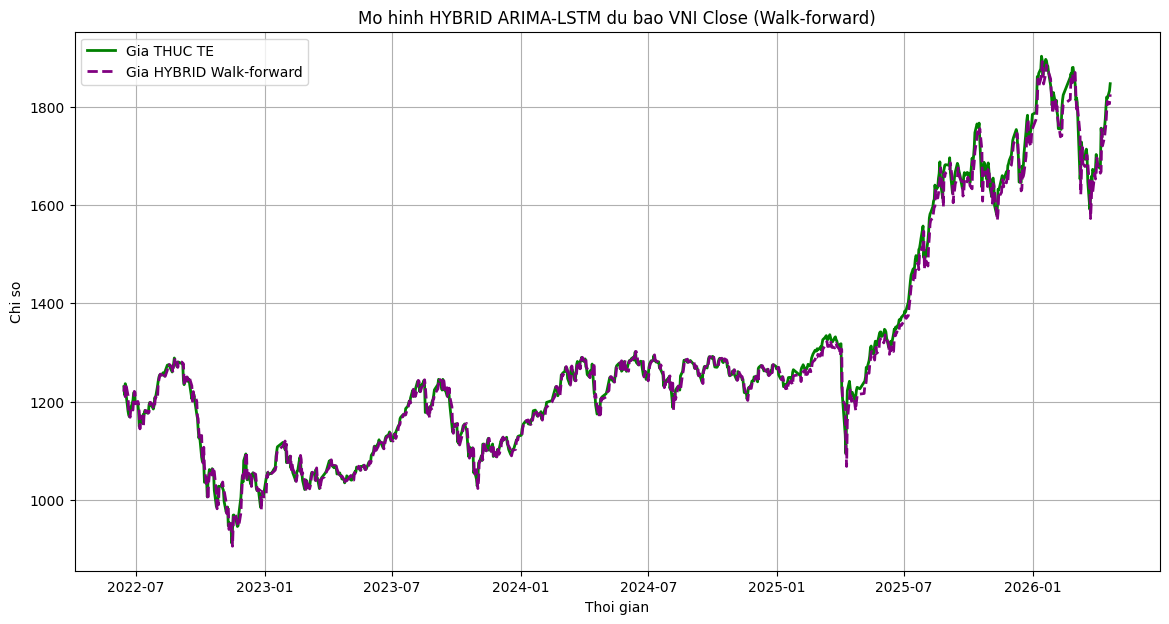

In [26]:
# %pip install tensorflow scikit-learn



from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import tensorflow as tf



np.random.seed(42)

tf.random.set_seed(42)



print('=== GIAI DOAN 1: CHUAN BI DU LIEU ===')

hybrid_df = df.copy()



# Ensure all features are numeric

for c in ['Open', 'High', 'Low', 'Close']:

    hybrid_df[c] = hybrid_df[c].apply(parse_number)

hybrid_df['Volume'] = hybrid_df['Volume'].apply(parse_volume)



hybrid_df = hybrid_df.sort_values('Date').dropna(subset=['Close']).reset_index(drop=True)

feature_cols = ['Volume', 'Open', 'High', 'Low']

hybrid_df[feature_cols] = hybrid_df[feature_cols].ffill().bfill()

hybrid_df = hybrid_df.set_index('Date')



train_size = int(len(hybrid_df) * 0.8)

train_df = hybrid_df.iloc[:train_size].copy()

test_df = hybrid_df.iloc[train_size:].copy()



train_price = train_df['Close'].astype(float)

test_price = test_df['Close'].astype(float)

print(f'So dong Train: {len(train_df)} | So dong Test: {len(test_df)}')



print('\n=== GIAI DOAN 2: ARIMA WALK-FORWARD (NO FUTURE LEAK) ===')

arima_order = (5, 1, 0)

arima_model = ARIMA(train_price, order=arima_order)

arima_result = arima_model.fit()



# Train residuals

train_df['ARIMA_Pred'] = arima_result.fittedvalues

train_df['Residuals'] = train_df['Close'] - train_df['ARIMA_Pred']

train_resid_df = train_df.dropna(subset=['Residuals']).copy()



# Strict one-step walk-forward: forecast t using data up to t-1, then update with actual y_t

rolling_result = arima_result

arima_test_preds = []

for y_t in test_price.values:

    forecast_one = rolling_result.forecast(steps=1)

    next_pred = float(forecast_one.iloc[0])

    arima_test_preds.append(next_pred)

    rolling_result = rolling_result.append([y_t], refit=False)

arima_test_preds = np.array(arima_test_preds)



print('\n=== GIAI DOAN 3: LSTM HOC PHAN DU ===')

features = ['Residuals', 'Volume', 'Open', 'High', 'Low']

train_feat = train_resid_df[features].values



scaler = MinMaxScaler(feature_range=(0, 1))

scaled_train = scaler.fit_transform(train_feat)



time_step = 60

def create_dataset(dataset, step=1):

    X, y = [], []

    for i in range(len(dataset) - step):

        X.append(dataset[i:(i + step), :])

        y.append(dataset[i + step, 0])

    return np.array(X), np.array(y)



X_train_full, y_train_full = create_dataset(scaled_train, time_step)

val_size = max(1, int(len(X_train_full) * 0.1))

X_train, y_train = X_train_full[:-val_size], y_train_full[:-val_size]

X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]



model = Sequential()

model.add(LSTM(units=48, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.25))

model.add(LSTM(units=24, return_sequences=False))

model.add(Dropout(0.25))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')



callbacks = [

    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),

    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

]



print('Dang huan luyen LSTM tren phan du...')

history = model.fit(

    X_train,

    y_train,

    validation_data=(X_val, y_val),

    epochs=30,

    batch_size=32,

    verbose=0,

    shuffle=False,

    callbacks=callbacks

)

print(f"Epoch da dung: {len(history.history['loss'])}")



# Calibrate residual correction strength on validation (train-only)

val_scaled_pred = model.predict(X_val, verbose=0)

dummy_val = np.zeros((len(val_scaled_pred), len(features)))

dummy_val[:, 0] = val_scaled_pred[:, 0]

val_res_pred = scaler.inverse_transform(dummy_val)[:, 0]



dummy_y_val = np.zeros((len(y_val), len(features)))

dummy_y_val[:, 0] = y_val

val_res_true = scaler.inverse_transform(dummy_y_val)[:, 0]



den = float(np.dot(val_res_pred, val_res_pred))

if den > 0:

    residual_weight = float(np.dot(val_res_true, val_res_pred) / den)

else:

    residual_weight = 1.0

residual_weight = float(np.clip(residual_weight, 0.2, 1.2))

print(f'Residual weight (calibrated): {residual_weight:.3f}')



print('\n=== GIAI DOAN 4: HYBRID WALK-FORWARD TEST ===')

# Residual forecast each day, then update window with realized residual (available after day close)

window_scaled = scaled_train[-time_step:, :].copy()

test_exog = test_df[['Volume', 'Open', 'High', 'Low']].values

actual_test_price = test_price.values



final_hybrid_pred = []



for i in range(len(test_df)):

    x_input = window_scaled.reshape(1, time_step, len(features))

    pred_res_scaled = model.predict(x_input, verbose=0)[0, 0]



    dummy = np.zeros((1, len(features)))

    dummy[0, 0] = pred_res_scaled

    pred_residual = scaler.inverse_transform(dummy)[0, 0]



    yhat = arima_test_preds[i] + residual_weight * pred_residual

    final_hybrid_pred.append(yhat)



    # Update window with realized residual at current step (strictly past info for next step)

    realized_residual = actual_test_price[i] - arima_test_preds[i]

    next_row_raw = np.array([

        realized_residual,

        test_exog[i, 0],

        test_exog[i, 1],

        test_exog[i, 2],

        test_exog[i, 3]

    ], dtype=float).reshape(1, -1)

    next_row_scaled = scaler.transform(next_row_raw)

    window_scaled = np.vstack([window_scaled[1:], next_row_scaled])



final_hybrid_pred = np.array(final_hybrid_pred)

test_dates = test_df.index



valid_mask = np.isfinite(final_hybrid_pred) & np.isfinite(actual_test_price)

final_hybrid_pred = final_hybrid_pred[valid_mask]

actual_test_price = actual_test_price[valid_mask]

test_dates = test_dates[valid_mask]



rmse = np.sqrt(mean_squared_error(actual_test_price, final_hybrid_pred))

mae = mean_absolute_error(actual_test_price, final_hybrid_pred)

mape = mean_absolute_percentage_error(actual_test_price, final_hybrid_pred) * 100



print('\n=== KET QUA TEST CUA HYBRID WALK-FORWARD (ARIMA + LSTM) ===')

print(f'ARIMA order: {arima_order}')

print(f'RMSE : {rmse:.3f}')

print(f'MAE  : {mae:.3f}')

print(f'MAPE : {mape:.3f}%')



plt.figure(figsize=(14, 7))

plt.plot(test_dates, actual_test_price, label='Gia THUC TE', color='green', linewidth=2)

plt.plot(test_dates, final_hybrid_pred, label='Gia HYBRID Walk-forward', color='purple', linestyle='--', linewidth=2)

plt.title('Mo hinh HYBRID ARIMA-LSTM du bao VNI Close (Walk-forward)')

plt.xlabel('Thoi gian')

plt.ylabel('Chi so')

plt.legend()

plt.grid(True)

plt.show()

Training standalone LSTM...
Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0045 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0022 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0021 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0017 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0017 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0015 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0014 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 8/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0015 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 9/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0012 - val_loss: 0.01

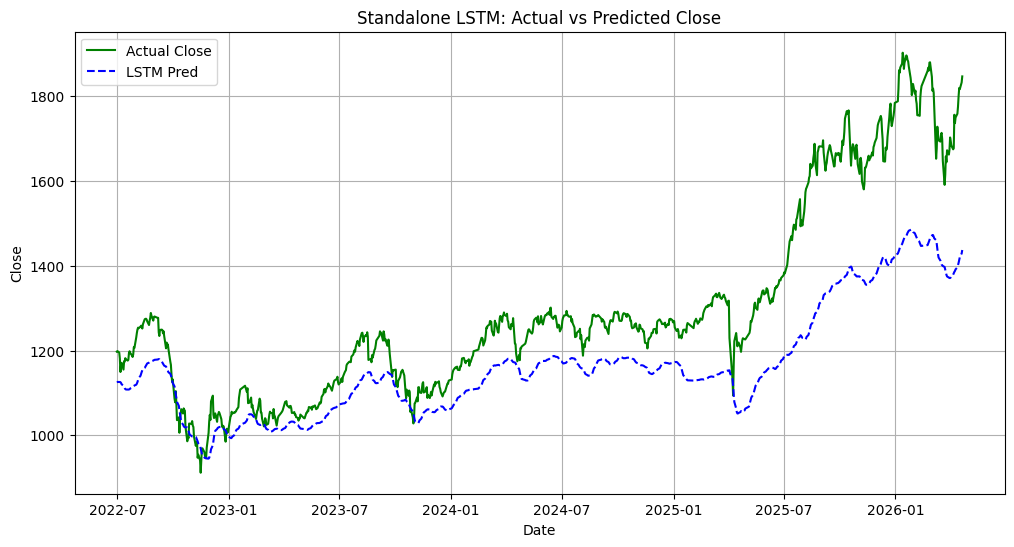

In [27]:
# Standalone LSTM: train and evaluate predicting `Close` (multivariate inputs)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# Prepare data (use existing `df`)
data_lstm = df.copy()
date_col = 'Date'
if date_col in data_lstm.columns:
    data_lstm[date_col] = pd.to_datetime(data_lstm[date_col])
    data_lstm = data_lstm.sort_values(date_col).set_index(date_col)

features = ['Close', 'Volume', 'Open', 'High', 'Low']
data_lstm = data_lstm[features].ffill().bfill().astype(float)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_lstm.values)

time_step = 60

def create_dataset(dataset, step=1):
    X, y = [], []
    for i in range(len(dataset) - step):
        X.append(dataset[i:(i + step), :])
        y.append(dataset[i + step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled, time_step)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Build model
model_lstm = Sequential()
model_lstm.add(LSTM(48, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dropout(0.25))
model_lstm.add(LSTM(24, return_sequences=False))
model_lstm.add(Dropout(0.25))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
]

print('Training standalone LSTM...')
history = model_lstm.fit(X_train, y_train, validation_split=0.1, epochs=30, batch_size=32, verbose=1, shuffle=False, callbacks=callbacks)

# Predict and inverse transform
pred_scaled = model_lstm.predict(X_test)

dummy_pred = np.zeros((len(pred_scaled), scaled.shape[1]))
dummy_pred[:, 0] = pred_scaled[:, 0]
pred_inv = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_y = np.zeros((len(y_test), scaled.shape[1]))
dummy_y[:, 0] = y_test
y_inv = scaler.inverse_transform(dummy_y)[:, 0]

# Metrics
rmse = np.sqrt(mean_squared_error(y_inv, pred_inv))
mae = mean_absolute_error(y_inv, pred_inv)
mape = mean_absolute_percentage_error(y_inv, pred_inv) * 100

print('\nStandalone LSTM results:')
print(f'RMSE: {rmse:.3f}')
print(f'MAE : {mae:.3f}')
print(f'MAPE: {mape:.3f}%')

# Plot
plt.figure(figsize=(12,6))
idx = data_lstm.index[-len(y_inv):]
plt.plot(idx, y_inv, label='Actual Close', color='green')
plt.plot(idx, pred_inv, label='LSTM Pred', color='blue', linestyle='--')
plt.title('Standalone LSTM: Actual vs Predicted Close')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.show()
